In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.linalg import expm

import sys  
sys.path.insert(1, '../python_files/')
import qubits
import pulses

### Transmonin määrittely

In [2]:
E_C = 0.3*2*np.pi #Varausenergia (GHz)
E_J = 8*2*np.pi #Josephsonin energia (GHz)

qubit=qubits.Transmon(E_C,E_J,500)

In [3]:
print("Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0")
print(qubit.energies[0:11]-qubit.energies[0])

Transmonin yksitoista ensimmäistä energiatasoa (GHz), kun E_0=0
[  0.          25.48860139  48.57030326  69.5813038   82.4548144
 109.4189376  110.44497738 160.29841201 160.30648659 227.12458838
 227.12460681]


In [4]:
AC_stark_vals=[-0.3065898535663432]
AC_stark_vals_ef=[-2.206589853566343]
A_vals=[12.060132973240993]

## Simulaatio

In [5]:
f_ef = qubit.energies[2]-qubit.energies[1] #ef-siirtymän taajuus

dim = 7

evolution_eigenbasis=qubits.time_evolution(qubit.H_D_eigbasis(dim))

### Simulaatio alkuperäiselle pulssille

In [6]:
def sim_pulse(f_d,f_supp,A,evolution,dim,f_rabi,K=20,t_ramp=5,verbose=False,p=1):
    T_floquet = 2*np.pi/(f_d) #Floquet-jakson pituus
    dt = T_floquet/K #Diskretoidaan aika-avaruus siten, että Floquet-jakson pituus on K aikapistettä

    t_gap=np.pi/(f_supp)
    t_ramp_new=t_ramp-t_gap/2

    phi=t_gap*f_d
    
    N_edge1 = int((t_ramp_new*2+t_gap/2)/dt)
    N_edge2 = int((t_ramp_new*2-t_gap/2)/dt)

    N_pulse=int(2*np.pi/(f_rabi*dt)) #Määritellään pulssin pituus arvatun Rabi-taajuuden perusteella

    #Kokonainen pulssi rampin aikakehityksen sekä Floquet-operaattorin laskemista varten
    pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,N_pulse,N_edge1],time_unit=dt,offset_input=-phi/2)
    pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp_new*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,N_pulse,N_edge2],time_unit=dt,offset_input=phi/2)

    combined_pulse = pulse1.raw + pulse2.raw
    m = 2*np.abs(np.cos(phi/2))

    if verbose:
        plt.figure()
        plt.plot(pulse1.time_vals,combined_pulse/m)
        plt.plot(pulse1.time_vals,(pulse1.envelope + pulse2.envelope)/2)
        plt.xlabel("Aika (ms)")
        plt.xlim([5,10])
        plt.ylabel("Normalisoitu amplitudi")
        plt.title("Yhdistetty pulssi")
        plt.show()

    U_floquet=evolution.U_floquet(A*combined_pulse[N_edge1:N_edge1+K]/m,dt)
    U_floquet=np.linalg.matrix_power(U_floquet,p)

    #Alustetaan kubitin tila perustilaan
    psi_eig_accum = np.zeros(dim, dtype=complex)
    psi_eig_accum[0] = 1

    #Lopulliset todennäköisyydet eripituisten pulssien jälkeen
    last_vals=[]

    for i in range(0, N_edge1): #Aikakehitys nousevalle rampille
        psi_eig_accum = evolution.U(A*combined_pulse[i]/m, dt) @ psi_eig_accum

    #Simuloitujen pulssien määrä/K koska jokainen simulaatio edistää tilaa yhden Floquet-jakson (K*dt)
    N_sim=int(N_pulse/(K*p))

    #Simulaatio pulsseille
    for k in range(0,N_sim):
        psi_eig = psi_eig_accum

        #Laskevan rampin simulaatio
        pulse1 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2-t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge2,K*p*k,N_edge1],time_unit=dt,offset_input=-phi/2)
        pulse2 = pulses.Pulse(f_d,f_supp,[pulses.gaussian(t_ramp*2+t_gap/2,t_ramp_new/2),pulses.one,pulses.gaussian_opp(0,t_ramp_new/2)],[N_edge1,K*p*k,N_edge2],time_unit=dt,offset_input=phi/2)
        combined_pulse = pulse1.raw + pulse2.raw

        remainder = len(combined_pulse)-N_edge1-K*p*k

        for i in range(0, remainder): #Aikakehitys
            psi_eig = evolution_eigenbasis.U(A*combined_pulse[N_edge1+K*p*k+i]/m, dt) @ psi_eig
        last_vals.append(np.abs(psi_eig)**2)
        psi_eig_accum = U_floquet @ psi_eig_accum #Kehitetään kubitin tilaa yhdellä Floquet-jaksolla


    #e- ja f-tasojen lopulliset todennäköisyydet
    e_vals = np.array([a[1] for a in last_vals])
    f_vals = np.array([a[2] for a in last_vals])

    #e-tason suurin todennäköisyys
    excited_max=max(e_vals)
    #f-tason suurin todennäköisyys pulssille, jolla e-taso saavuttaa suurimman arvonsa
    f_max=max(f_vals)

    #Simuloitujen pulssien pituudet, plottausta varten
    pulse_times=np.arange(0,N_pulse)*K*p*dt + 2*t_ramp

    #Pulssin pituus määritettynä maksimiarvon sijainnin perusteella
    index = np.argmax(e_vals)
    T_pulse = pulse_times[index]
    
    return (excited_max,f_max,T_pulse,last_vals,pulse_times)

def find_params(f_d,f_supp,A,evolution,f_rabi,AC_stark_d,AC_stark_supp,lims,scales,verbose=True):

    #Rajat AC-stark siirtymälle
    min_range_d = lims[0][0]
    max_range_d = lims[0][1]

    min_range_supp = lims[1][0]
    max_range_supp = lims[1][1]
    
    e_data=[]
    f_data=[]
    
    AC_stark_vals_d=np.arange(min_range_d,max_range_d)/scales[0]+AC_stark_d
    AC_stark_vals_supp=np.arange(min_range_supp,max_range_supp)/scales[1]+AC_stark_supp
    
    for i in range(min_range_d,max_range_d):
        print(i)
        delta_d=AC_stark_d+i/scales[0]
        
        max_e_vals=[]
        max_f_vals=[]
        
        for j in range(min_range_supp,max_range_supp):

            delta_supp=AC_stark_supp+j/scales[1] #AC-stark siirtymä
    
            sim_vals = sim_pulse(f_d+delta_d,f_supp+delta_supp,A,evolution,dim,f_rabi,t_ramp=10,p=1)
    
            max_e_vals.append(sim_vals[0])
            max_f_vals.append(sim_vals[1])

        e_data.append(max_e_vals)
        f_data.append(max_f_vals)

    xtick_locs=np.arange(0,1, step=0.2)*len(AC_stark_vals_d)
    ytick_locs=np.arange(0,1, step=0.2)*len(AC_stark_vals_supp)

    xlabels=[round(AC_stark_vals_d[int(i)],3) for i in xtick_locs]
    ylabels=[round(AC_stark_vals_supp[int(i)],3) for i in ytick_locs]

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(e_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_d-ω_q")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="e-tason suurin todennäköisyys")
    plt.show()

    plt.figure(figsize=(6, 6))
    plt.imshow(np.array(f_data).T, origin='lower', cmap='inferno', norm=LogNorm(), aspect='auto')    
    plt.xlabel("ω_d-ω_q")
    plt.xticks(xtick_locs,xlabels)
    plt.ylabel("ω_supp-ω_ef")
    plt.yticks(ytick_locs,ylabels)
    plt.colorbar(label="f-tason suurin todennäköisyys")
    plt.show()

    if verbose:
        print(e_data)
        print(f_data)

    e_means = [np.mean(arr) for arr in e_data]
    e_index = np.argmax(e_means)
    f_index = np.argmin(f_data[e_index])
    
    delta_d=AC_stark_vals_d[e_index]
    delta_supp=AC_stark_vals_supp[f_index]
    
    return(delta_d,delta_supp)

-40


-39


-38


-37


-36


...

35


36


37


38


39


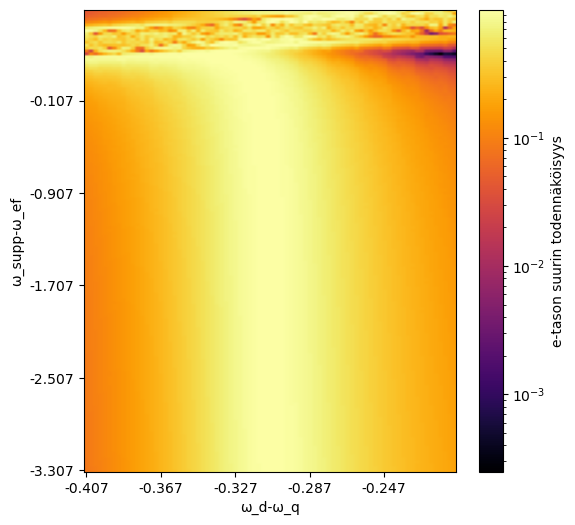

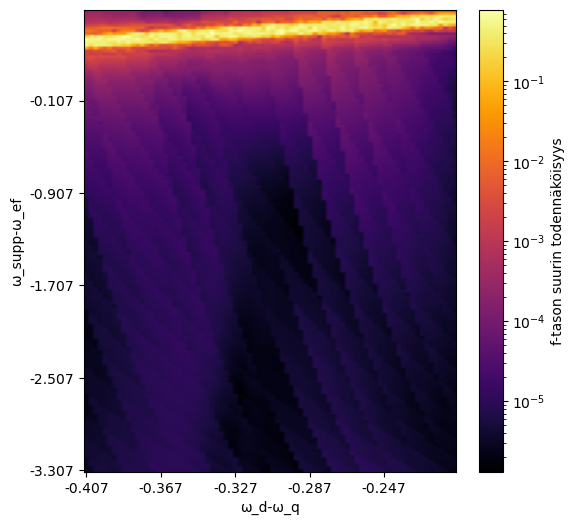

[[np.float64(0.08444273555367149), np.float64(0.08462524185577529), np.float64(0.08480663760222185), np.float64(0.08498703530061494), np.float64(0.0851665442103416), np.float64(0.08599610321549632), np.float64(0.08617399134061177), np.float64(0.08635116066213526), np.float64(0.08652771050321599), np.float64(0.08670373820583453), np.float64(0.08687933933842562), np.float64(0.0870546078935915), np.float64(0.08700177560278831), np.float64(0.08717148393379653), np.float64(0.08734112426753292), np.float64(0.08751078334840326), np.float64(0.0876805471818137), np.float64(0.08785050118954549), np.float64(0.08802073036102487), np.float64(0.08785484170061049), np.float64(0.08802065580796736), np.float64(0.08818706207492882), np.float64(0.08835414489597183), np.float64(0.0885219888572361), np.float64(0.08869067888057769), np.float64(0.08886030036705085), np.float64(0.08903093934078037), np.float64(0.08880403732362228), np.float64(0.08898180597239036), np.float64(0.08916108034173516), np.float64(0

Amplitudi (GHz): 12.060132973240993
Ajotaajuus AC Stark (GHz): -0.3090898535663432
Hiljennetty taajuus AC Stark (GHz): -3.306589853566343
E-tason suurin todennäköisyys: 0.9967865713227514
F-tason suurin todennäköisyys: 1.752978823522365e-06


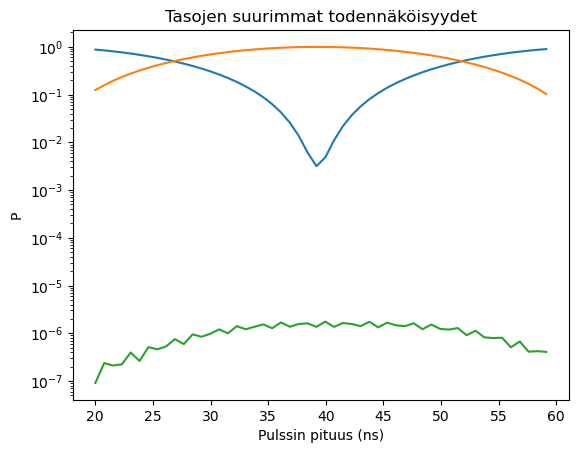

---------------------------------------------


In [7]:
f_d=qubit.frequency/3
f_supp=f_ef/3
A=A_vals[0]
f_rabi=2*np.pi/40

AC_stark_vals_d=[]
AC_stark_vals_supp=[]

params=find_params(f_d,f_supp,A,evolution_eigenbasis,f_rabi,AC_stark_vals[0],AC_stark_vals[0],[[-40,40],[-120,40]],[400,40])
AC_stark_vals_d.append(params[0])
AC_stark_vals_supp.append(params[1])

m=1

vals = sim_pulse(f_d+AC_stark_vals_d[-1],f_supp+AC_stark_vals_supp[-1],A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,p=1)

print("Amplitudi (GHz):", A)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals_d[-1])
print("Hiljennetty taajuus AC Stark (GHz):", AC_stark_vals_supp[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")

Amplitudi (GHz): 12.060132973240993
Ajotaajuus AC Stark (GHz): -0.3065898535663432
E-tason suurin todennäköisyys: 0.9967865713227514
F-tason suurin todennäköisyys: 1.752978823522365e-06


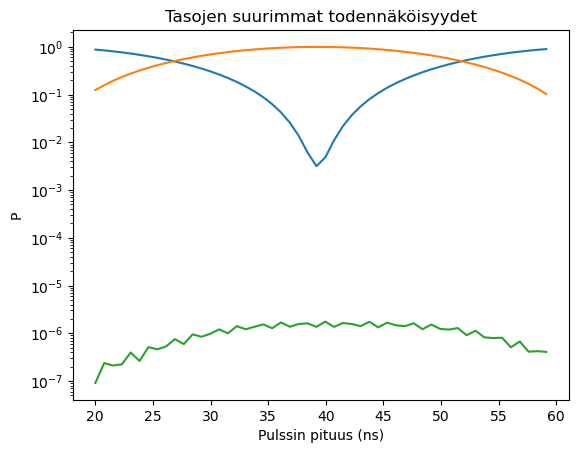

---------------------------------------------


In [8]:
m=1

f_d=qubit.frequency/3
f_supp=f_ef/3
A=A_vals[0]
f_rabi=2*np.pi/40

vals = sim_pulse(f_d-0.3090898535663432,f_supp+AC_stark_vals_supp[-1],A,evolution_eigenbasis,dim,f_rabi/m,t_ramp=10,p=1)

print("Amplitudi (GHz):", A)

print("Ajotaajuus AC Stark (GHz):", AC_stark_vals[-1])

print("E-tason suurin todennäköisyys:", vals[0])
print("F-tason suurin todennäköisyys:", vals[1])

g_vals=np.array([arr[0] for arr in vals[3]])
e_vals=np.array([arr[1] for arr in vals[3]])
f_vals=np.array([arr[2] for arr in vals[3]])

n_picked = int(len(vals[3])/m) #Plottausta varten käytetty pisteiden määrä

plt.figure()
plt.semilogy(vals[4][:n_picked], g_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], e_vals[:n_picked])
plt.semilogy(vals[4][:n_picked], f_vals[:n_picked])
plt.xlabel("Pulssin pituus (ns)")
plt.ylabel("P")
plt.title("Tasojen suurimmat todennäköisyydet")
plt.show()

print("---------------------------------------------")